# 08 — Blend v2 (with Re-tuned XGBoost)

Replaces the original XGBoost OOF with the v2 (notebook 07) OOF, then re-runs the SLSQP weight optimisation.

Outputs:
- `outputs/submission_blend_v2.csv` ← byte-safe, integer predictions, Kaggle-ready
- `outputs/blend_v2_weights.json`

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')

In [2]:
y = pd.read_csv(DATA_DIR / 'reserve_2016Q3_train.csv')['NumReserveDays2016Q3'].astype(float).values
test_ids = pd.read_csv(DATA_DIR / 'PropertyID_test.csv')['PropertyID'].values

# Use v2 OOF in place of v1 XGBoost
oof_files = {
    'DecisionTree':     'oof_DecisionTree.npy',
    'RandomForest':     'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoostV2':        'oof_XGBoostV2.npy',
    'MLP':              'oof_MLP.npy',
}
sub_files = {
    'DecisionTree':     'submission_baseline_DecisionTree.csv',
    'RandomForest':     'submission_baseline_RandomForest.csv',
    'GradientBoosting': 'submission_baseline_GradientBoosting.csv',
    'XGBoostV2':        'submission_xgboost_v2.csv',
    'MLP':              'submission_mlp.csv',
}

oofs, subs = {}, {}
for name, oof_name in oof_files.items():
    p_oof = OUT_DIR / oof_name
    p_sub = OUT_DIR / sub_files[name]
    if p_oof.exists() and p_sub.exists():
        oofs[name] = np.clip(np.load(p_oof), 0, 92)
        # submission files come in two formats — original (Property[Q3]_test,Pred) and the
        # final integer one (PropertyID_test,Pred). Handle both.
        df_sub = pd.read_csv(p_sub)
        if 'Property[Q3]_test' in df_sub.columns:
            df_sub = df_sub.rename(columns={'Property[Q3]_test': 'PropertyID_test'})
        # align order to test_ids
        df_sub = df_sub.set_index('PropertyID_test').loc[test_ids].reset_index()
        subs[name] = df_sub['Pred'].astype(float).values
        mse = mean_squared_error(y, oofs[name])
        print(f'{name:<18s} | OOF MSE = {mse:8.3f}')
    else:
        print(f'{name:<18s} | MISSING ({oof_name} or {sub_files[name]})')

model_names = [m for m in oofs.keys() if m in subs]
print('\nModels in blend:', model_names)

DecisionTree       | OOF MSE =  239.539
RandomForest       | OOF MSE =  196.231
GradientBoosting   | OOF MSE =  183.790
XGBoostV2          | OOF MSE =  223.322
MLP                | OOF MSE =  215.651

Models in blend: ['DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoostV2', 'MLP']


In [3]:
oof_mat  = np.column_stack([oofs[m] for m in model_names])
test_mat = np.column_stack([subs[m] for m in model_names])
print('oof_mat:', oof_mat.shape, '| test_mat:', test_mat.shape)

# Equal-weight baseline
blend_eq = np.clip(oof_mat.mean(axis=1), 0, 92)
print(f'Equal-weight blend OOF MSE = {mean_squared_error(y, blend_eq):.3f}')

oof_mat: (24372, 5) | test_mat: (24318, 5)
Equal-weight blend OOF MSE = 187.765


In [4]:
def blend_mse(w, M, y):
    return float(mean_squared_error(y, np.clip(M @ w, 0, 92)))

k = oof_mat.shape[1]
w0 = np.full(k, 1.0 / k)
res = minimize(blend_mse, w0, args=(oof_mat, y),
               method='SLSQP', bounds=[(0.0, 1.0)] * k,
               constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}],
               options={'maxiter': 500, 'ftol': 1e-9})
w = res.x; w[w < 1e-4] = 0.0; w = w / w.sum()
print('Optimal weights:')
for m, wi in zip(model_names, w):
    print(f'  {m:<18s} = {wi:.4f}')
print(f'\nOptimal blend OOF MSE = {blend_mse(w, oof_mat, y):.3f}')

with open(OUT_DIR / 'blend_v2_weights.json', 'w') as f:
    json.dump({m: float(wi) for m, wi in zip(model_names, w)}, f, indent=2)

Optimal weights:
  DecisionTree       = 0.0159
  RandomForest       = 0.1056
  GradientBoosting   = 0.7159
  XGBoostV2          = 0.0000
  MLP                = 0.1626

Optimal blend OOF MSE = 182.185


In [5]:
# Build final test prediction and write byte-safe CSV
final = np.clip(test_mat @ w, 0, 92)
final_int = np.clip(np.round(final), 0, 92).astype(int)

lines = [b'PropertyID_test,Pred\n']
for i, p in zip(test_ids, final_int):
    lines.append(f'{int(i)},{int(p)}\n'.encode('ascii'))
(OUT_DIR / 'submission_blend_v2.csv').write_bytes(b''.join(lines))

chk = pd.read_csv(OUT_DIR / 'submission_blend_v2.csv')
print(f'Wrote submission_blend_v2.csv | rows={len(chk)} NaN={chk.isna().sum().sum()} '
      f'header={list(chk.columns)} dtype={chk["Pred"].dtype}')
chk.head()

Wrote submission_blend_v2.csv | rows=24318 NaN=0 header=['PropertyID_test', 'Pred'] dtype=int64


,PropertyID_test,Pred
0,795,0
1,2515,56
2,2595,6
3,5099,32
4,5107,27


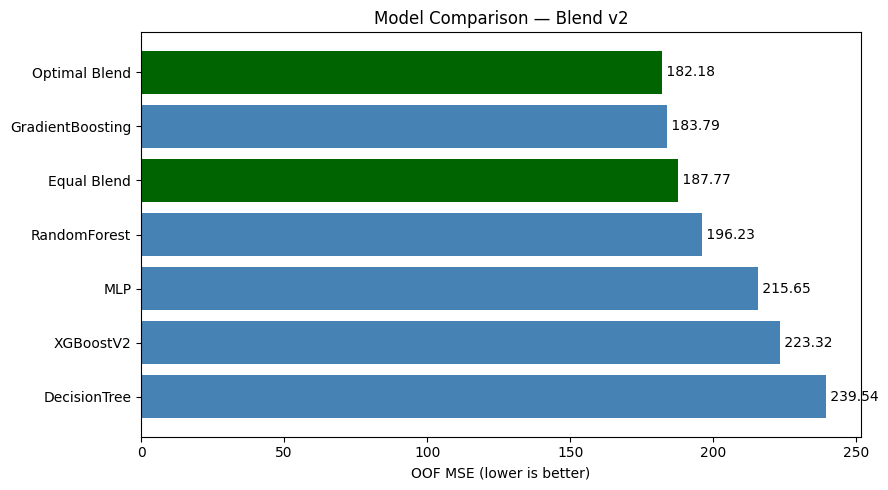

In [6]:
# Comparison plot
scores = {m: mean_squared_error(y, oofs[m]) for m in model_names}
scores['Equal Blend']   = mean_squared_error(y, blend_eq)
scores['Optimal Blend'] = blend_mse(w, oof_mat, y)
s = pd.Series(scores).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['darkgreen' if 'Blend' in n else 'steelblue' for n in s.index]
ax.barh(s.index, s.values, color=colors)
for i, v in enumerate(s.values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.invert_yaxis()
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — Blend v2')
plt.tight_layout(); plt.savefig(OUT_DIR / 'blend_v2_comparison.png', dpi=120); plt.show()